<a href="https://colab.research.google.com/github/Ckirschner1989/Projeto-1/blob/main/Projeto.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [42]:
import pandas as pd
import numpy as np
import random
import os
import re
import json
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timedelta

In [43]:
df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/Projeto 1/US Superstore data (1).csv')
print(f"{len(df)} linhas carregadas.")
print(df.head())

9999 linhas carregadas.
   Row ID        Order ID  Order Date   Ship Date       Ship Mode Customer ID  \
0     1.0  CA-2016-152156  11/08/2016  11/11/2016    Second Class    CG-12520   
1     2.0  CA-2016-152156  11/08/2016  11/11/2016    Second Class    CG-12520   
2     3.0  CA-2016-138688  06/12/2016  06/16/2016    Second Class    DV-13045   
3     4.0  US-2015-108966  10/11/2015  10/18/2015  Standard Class    SO-20335   
4     5.0  US-2015-108966  10/11/2015  10/18/2015  Standard Class    SO-20335   

     Customer Name    Segment        Country             City  ...  \
0      Claire Gute   Consumer  United States        Henderson  ...   
1      Claire Gute   Consumer  United States        Henderson  ...   
2  Darrin Van Huff  Corporate  United States      Los Angeles  ...   
3   Sean O'Donnell   Consumer  United States  Fort Lauderdale  ...   
4   Sean O'Donnell   Consumer  United States  Fort Lauderdale  ...   

  Postal Code  Region       Product ID         Category Sub-Category

# Nova secção

In [44]:
def inspecionar_dataset(df, exibir_cabecalho=True):
    """
    Realiza uma inspeção inicial completa em um DataFrame pandas.
    """
    print('\n=== INSPEÇÃO INICIAL DO DATASET ===')
    print(f'Shape: {df.shape}')
    print(f'\nColunas:\n{list(df.columns)}')
    print(f'\nTipos de dados:\n{df.dtypes}')
    print(f'\nValores nulos por coluna:\n{df.isnull().sum()}')
    print(f'\nPrimeiros registros:\n{df.head()}')
    print(f'\nEstatísticas descritivas:\n{df.describe()}')
    print(f'\nValores únicos por coluna:\n{df.nunique()}')
    print(f'\nValores duplicados: {df.duplicated().sum()}')
    print('=' * 35)
    return df.describe(include="all")
inspecionar_dataset(df)


=== INSPEÇÃO INICIAL DO DATASET ===
Shape: (9999, 21)

Colunas:
['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode', 'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State', 'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category', 'Product Name', 'Sales', 'Quantity', 'Discount', 'Profit']

Tipos de dados:
Row ID           float64
Order ID          object
Order Date        object
Ship Date         object
Ship Mode         object
Customer ID       object
Customer Name     object
Segment           object
Country           object
City              object
State             object
Postal Code      float64
Region            object
Product ID        object
Category          object
Sub-Category      object
Product Name      object
Sales            float64
Quantity         float64
Discount         float64
Profit           float64
dtype: object

Valores nulos por coluna:
Row ID           2
Order ID         1
Order Date       1
Ship Date        1
Ship Mode       

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
count,9997.000000,9998,9998,9998,9998,9998,9998,9998,9998,9998,...,9998.000000,9998,9998,9998,9998,9998,9998.000000,9998.000000,9998.000000,9998.000000
unique,NaN,5009,1237,1334,4,793,793,3,1,531,...,NaN,4,1862,3,17,1850,NaN,NaN,NaN,NaN
top,NaN,CA-2017-100111,09/05/2016,12/16/2015,Standard Class,WB-21850,William Brown,Consumer,United States,New York City,...,NaN,West,OFF-PA-10001970,Office Supplies,Binders,Staple envelope,NaN,NaN,NaN,NaN
freq,NaN,14,38,35,5970,37,37,5194,9998,915,...,NaN,3204,19,6027,1524,48,NaN,NaN,NaN,NaN
mean,4997.014404,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,55185.245749,NaN,NaN,NaN,NaN,NaN,229.875755,3.789858,0.156180,28.659211
std,2885.995826,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,32064.819358,NaN,NaN,NaN,NaN,NaN,623.164034,2.224912,0.206423,234.214243
min,1.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,1040.000000,NaN,NaN,NaN,NaN,NaN,0.444000,1.000000,0.000000,-6599.978000
25%,2498.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,23223.000000,NaN,NaN,NaN,NaN,NaN,17.280000,2.000000,0.000000,1.728750
50%,4997.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,56301.000000,NaN,NaN,NaN,NaN,NaN,54.490000,3.000000,0.200000,8.671250
75%,7496.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,90008.000000,NaN,NaN,NaN,NaN,NaN,209.940000,5.000000,0.200000,29.364000


In [45]:
from pandas.core.tools.datetimes import to_datetime
def normalizar_texto(texto):
  if pd.isna(texto):
    return texto
  texto = str(texto)
  texto = re.sub(r"\s+", " ", texto)   # colapsa espacos repetidos
  return texto.strip()                 # remove espacos das pontas

def limpar_strings(df, colunas):
    df=df.copy()
    for coluna in colunas:
     df[coluna] = df[coluna].apply(normalizar_texto)
    return df

def limpar_dados(df):
  df=df.copy()
  relatorio={}
  relatorio["registros_iniciais"] = len(df)
# Etapa 1: normalizar textos (espacos extras em Description e Country)
  df=limpar_strings(df, [])

  df = limpar_strings(df,["Ship Mode","Customer Name","Segment","Country", "City","State", "Category", "Sub-Category", "Product Name" ])
  #Etapa 2: converter a coluna de data para o tipo datetime, e remover linhas sem data valida
  # errors="coerce" transforma datas invalidas em vazio (NaT)
  df[["Order Date", "Ship Date"]]= df[["Order Date", "Ship Date"]].apply(pd.to_datetime, errors="coerce")
  antes=len(df)
  df=df.dropna(subset=["Order Date", "Ship Date"])
  relatorio["datas_invalidas_removidas"] = antes - len(df)

  #remover linhas sem cliente, nome do produto
  antes = len(df)
  df = df.dropna(subset=["Customer Name", "Product Name","Row ID"])
  relatorio["linhas_sem_cliente_ou_sem_descricao"] = antes - len(df)

  #remover linhas duplicadas

  df=df.drop_duplicates()
  relatorio["linhas_duplicadas"] = antes - len(df)

  #REMOVER PREÇOS nulos ou quantidade nula
  antes = len(df)
  df = df.dropna(subset=["Sales", "Quantity"])
  relatorio["linhas_sem_preco_ou_sem_quantidade"] = antes - len(df)

  #Ajustar o tipo do Order ID para string
  df["Order ID"] = df["Order ID"].astype(str)

  #Resumo final
  relatorio["registros_finais"] = len(df)
  relatorio["registros_removidos"] = relatorio["registros_iniciais"] - relatorio["registros_finais"]

  return df, relatorio
df_v1, relatorio = limpar_dados(df)

print("Relatório de limpeza")
for etapa, valor in relatorio.items():
  print(f"{etapa}: {valor}")

df_v1.to_csv("/content/drive/MyDrive/Colab Notebooks/Projeto 1US Superstore data (1)_v1.csv", index=False)
print("\nv1 salva em ../content/drive/MyDrive/Colab Notebooks/Projeto 1US Superstore data (1)_v1.csv")

Relatório de limpeza
registros_iniciais: 9999
datas_invalidas_removidas: 1
linhas_sem_cliente_ou_sem_descricao: 1
linhas_duplicadas: 4
linhas_sem_preco_ou_sem_quantidade: 0
registros_finais: 9994
registros_removidos: 5

v1 salva em ../content/drive/MyDrive/Colab Notebooks/Projeto 1US Superstore data (1)_v1.csv


In [46]:
inspecionar_dataset(df_v1)


=== INSPEÇÃO INICIAL DO DATASET ===
Shape: (9994, 21)

Colunas:
['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode', 'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State', 'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category', 'Product Name', 'Sales', 'Quantity', 'Discount', 'Profit']

Tipos de dados:
Row ID                  float64
Order ID                 object
Order Date       datetime64[ns]
Ship Date        datetime64[ns]
Ship Mode                object
Customer ID              object
Customer Name            object
Segment                  object
Country                  object
City                     object
State                    object
Postal Code             float64
Region                   object
Product ID               object
Category                 object
Sub-Category             object
Product Name             object
Sales                   float64
Quantity                float64
Discount                float64
Profit            

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
count,9994.000000,9994,9994,9994,9994,9994,9994,9994,9994,9994,...,9994.000000,9994,9994,9994,9994,9994,9994.000000,9994.000000,9994.000000,9994.000000
unique,NaN,5009,NaN,NaN,4,793,793,3,1,531,...,NaN,4,1862,3,17,1850,NaN,NaN,NaN,NaN
top,NaN,CA-2017-100111,NaN,NaN,Standard Class,WB-21850,William Brown,Consumer,United States,New York City,...,NaN,West,OFF-PA-10001970,Office Supplies,Binders,Staple envelope,NaN,NaN,NaN,NaN
freq,NaN,14,NaN,NaN,5968,37,37,5191,9994,915,...,NaN,3203,19,6026,1523,48,NaN,NaN,NaN,NaN
mean,4997.500000,NaN,2016-04-30 00:07:12.259355648,2016-05-03 23:06:58.571142912,NaN,NaN,NaN,NaN,NaN,NaN,...,55190.379428,NaN,NaN,NaN,NaN,NaN,229.858001,3.789574,0.156203,28.656896
min,1.000000,NaN,2014-01-03 00:00:00,2014-01-07 00:00:00,NaN,NaN,NaN,NaN,NaN,NaN,...,1040.000000,NaN,NaN,NaN,NaN,NaN,0.444000,1.000000,0.000000,-6599.978000
25%,2499.250000,NaN,2015-05-23 00:00:00,2015-05-27 00:00:00,NaN,NaN,NaN,NaN,NaN,NaN,...,23223.000000,NaN,NaN,NaN,NaN,NaN,17.280000,2.000000,0.000000,1.728750
50%,4997.500000,NaN,2016-06-26 00:00:00,2016-06-29 00:00:00,NaN,NaN,NaN,NaN,NaN,NaN,...,56430.500000,NaN,NaN,NaN,NaN,NaN,54.490000,3.000000,0.200000,8.666500
75%,7495.750000,NaN,2017-05-14 00:00:00,2017-05-18 00:00:00,NaN,NaN,NaN,NaN,NaN,NaN,...,90008.000000,NaN,NaN,NaN,NaN,NaN,209.940000,5.000000,0.200000,29.364000
max,9994.000000,NaN,2017-12-30 00:00:00,2018-01-05 00:00:00,NaN,NaN,NaN,NaN,NaN,NaN,...,99301.000000,NaN,NaN,NaN,NaN,NaN,22638.480000,14.000000,0.800000,8399.976000


In [47]:
#tratamento de outliers
def tratar_outliers(df_v1, colunas, metodo="remover"):
  df_v1=df_v1.copy()
  for col in colunas:
    q1,q3 = df_v1[col].quantile([0.25,0.75])
    iqr = q3-q1
    lim_inf = q1 - 1.5*iqr
    lim_sup = q3 + 1.5*iqr
    n_out = ((df_v1[col] < lim_inf) | (df_v1[col] > lim_sup)).sum()
    print(f"{col}:{n_out} outliers (lim_inf = {lim_inf:.2f}, lim_sup = {lim_sup:.2f})")
    if metodo == "remover":
      df_v1 = df_v1[(df_v1[col] >= lim_inf) & (df_v1[col] <= lim_sup)]
    else:
      df_v1[col] = df_v1[col].clip(lower=lim_inf, upper=lim_sup)
  return df_v1

tmp = df_v1.copy();tmp["Margem de lucro"] = tmp["Profit"] / tmp["Sales"]
df_v2 = tratar_outliers(tmp, ["Margem de lucro"], metodo = "remover")
df_v2 = df_v2.drop(columns=["Margem de lucro"])
print(f"V1={len(df_v1)} | v2= {len(df_v2)} | removidas = {len(df_v1) - len(df_v2)}")
df_v2.to_csv("/content/drive/MyDrive/Colab Notebooks/Projeto 1/US Superstore data (1)_v2.csv", index=False)
print("\nv2 salva em ../content/drive/MyDrive/Colab Notebooks/Projeto 1/US Superstore data (1)_v2.csv")

Margem de lucro:952 outliers (lim_inf = -0.36, lim_sup = 0.79)
V1=9994 | v2= 9042 | removidas = 952

v2 salva em ../content/drive/MyDrive/Colab Notebooks/Projeto 1/US Superstore data (1)_v2.csv


In [48]:
# adicionar coluna de margem de lucro percentual
def criar_colunas_derivadas(df_v2):
 df_v2 = df_v2.copy()
 df_v2["Margem de lucro"] = (df_v2["Profit"] / df_v2["Sales"])*100

#Criar uma coluna de ano e mês de venda
 df_v2["Ano_mes"] = df_v2["Order Date"].dt.to_period("M").astype(str)
 cond = [df_v2["Sales"]<=100, (df_v2["Sales"]>=101) & (df_v2["Sales"]<=1000000), df_v2["Sales"]>5000]
 df_v2["Faixa de faturamento"] = np.select(cond, ["Baixo", "Médio", "Alto"], default= "N/D")
 return df_v2
df_v2 = criar_colunas_derivadas(df_v2)
df_v2.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit,Margem de lucro,Ano_mes,Faixa de faturamento
0,1.0,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.960,2.0,0.0,41.9136,16.00,2016-11,Médio
1,2.0,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.940,3.0,0.0,219.5820,30.00,2016-11,Médio
2,3.0,CA-2016-138688,2016-06-12,2016-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.620,2.0,0.0,6.8714,47.00,2016-06,Baixo
4,5.0,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.368,2.0,0.2,2.5164,11.25,2015-10,Baixo
5,6.0,CA-2014-115812,2014-06-09,2014-06-14,Standard Class,BH-11710,Brosina Hoffman,Consumer,United States,Los Angeles,...,Furniture,Furnishings,Eldon Expressions Wood and Plastic Desk Access...,48.860,7.0,0.0,14.1694,29.00,2014-06,Baixo


In [49]:
#calcular métricas agregadas (groupby)
def calcular_metricas(df_v2):

   metricas = {}  # dicionário que vai guardar as quatro tabelas
   #Receita por mês
   metricas["por_mes"] = (
       df_v2.groupby("Ano_mes")
       .agg(
           receita_total=("Sales", "sum"),
           quantidade=("Quantity", "sum"),
           n_vendas=("Order ID", "count"),)

       .reset_index()
       .sort_values("Ano_mes")
   )

    # Top 5 produtos em vendas
   metricas["top_5_produtos_em_vendas"] = (
       df_v2.groupby("Product Name")["Sales"]
       .sum()
       .sort_values(ascending=False)
       .head(5)
       .reset_index()
    )

   # Receita por categoria
   metricas["receita_por_categoria"] = (
       df_v2.groupby("Category")["Sales"]
        .sum()
        .reset_index()
        .sort_values("Sales", ascending=False)
   )

    # Receita por estado
   metricas["receita_por_estado"] = (
       df_v2.groupby("State")["Sales"]
        .sum()
        .sort_values(ascending=False)
        .head(5)
        .reset_index()
   )
# percentual de lucro por categoria
   metricas["percentual_lucro_categoria"] = (
       df_v2.groupby("Category")["Margem de lucro"]
       .mean()
        #.apply(lambda x: x.mode().iloc[0] if not x.mode().empty else float('nan'))
        .sort_values(ascending=False)
        .head(50)
        .reset_index(name='Margem_de_Lucro_média')
   )

   #exibição dos dados
   for nome, tabela in metricas.items():
     print(f"\n{nome.upper().replace('_', ' ')}")
     print(tabela.to_string(index=False, float_format='%.2f'))
   return metricas
metricas = calcular_metricas(df_v2)


POR MES
Ano_mes  receita_total  quantidade  n_vendas
2014-01       13781.21      248.00        70
2014-02        4445.13      137.00        39
2014-03       53579.49      531.00       143
2014-04       27558.37      508.00       130
2014-05       22219.59      417.00       111
2014-06       33919.54      474.00       121
2014-07       31593.60      491.00       129
2014-08       26826.09      562.00       142
2014-09       75987.28      904.00       242
2014-10       29497.17      530.00       146
2014-11       76473.75     1125.00       291
2014-12       66000.18      962.00       241
2015-01       10961.20      196.00        52
2015-02       11886.04      227.00        59
2015-03       38487.65      484.00       129
2015-04       32493.15      488.00       143
2015-05       29825.96      517.00       133
2015-06       23120.81      426.00       123
2015-07       28066.93      507.00       126
2015-08       35755.03      549.00       144
2015-09       59654.17      980.00       262
2

In [50]:
def segmentar_clientes(df_v2):
    c=df_v2.groupby("Customer Name")["Sales"].sum().reset_index()
    c.columns = ["Customer Name", "Total Sales"]
    c["Segment"] = c["Total Sales"].apply(
        lambda g: "Ouro" if g > 20000 else "Prata" if g > 10000 else "Bronze")
    c = c.sort_values("Total Sales", ascending=False)
    print("Segmentação (Top10)");print(c.head(10).to_string(index=False))
    print("\nDistribuicao:\n", c["Segment"].value_counts())
    return c
clientes = segmentar_clientes(df_v2)

Segmentação (Top10)
     Customer Name  Total Sales Segment
       Sean Miller    24943.462    Ouro
      Tamara Chand    19026.172   Prata
      Raymond Buch    15106.062   Prata
      Tom Ashbrook    14511.348   Prata
      Sanjit Chand    14142.334   Prata
     Adrian Barton    13965.206   Prata
      Ken Lonsdale    13543.084   Prata
      Hunter Lopez    12873.298   Prata
Christopher Conant    12121.530   Prata
         Greg Tran    11820.120   Prata

Distribuicao:
 Segment
Bronze    772
Prata      19
Ouro        1
Name: count, dtype: int64


In [51]:
#Numpy
def calcular_estatisticas_numpy(df_v2):
   receitas = df_v2["Sales"].to_numpy()
   stats = {"media":float(np.mean(receitas)),"mediana":float(np.median(receitas)),
            "desvio_padrao":float(np.std(receitas)),"Total":float(np.sum(receitas)),
            "P25": float(np.percentile(receitas,25)), "P75":float(np.percentile(receitas,75))}
   receitas_pct = (receitas/receitas.sum())*100
   stats["Acima da média"] = int((receitas > stats["media"]).sum())
   print("Estatisticas Numpy")
   for k,v in stats.items():
     print(f"{k}: {v}")
   return stats
stats = calcular_estatisticas_numpy(df_v2)

Estatisticas Numpy
media: 240.17205831674409
mediana: 60.852000000000004
desvio_padrao: 638.3961684861615
Total: 2171635.7513
P25: 19.456
P75: 223.95
Acima da média: 2155


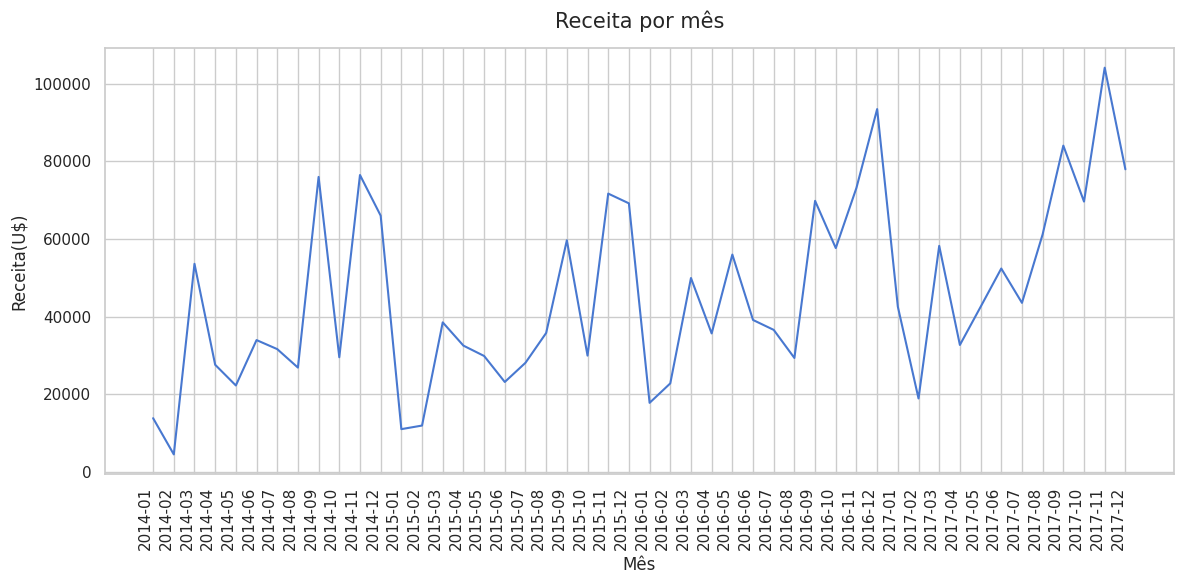

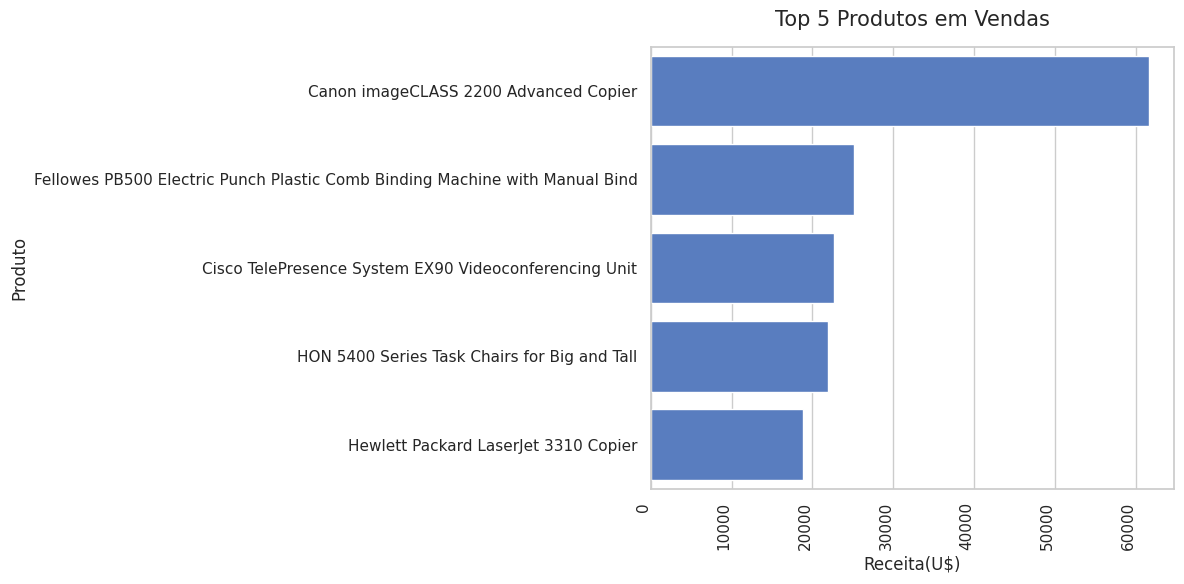

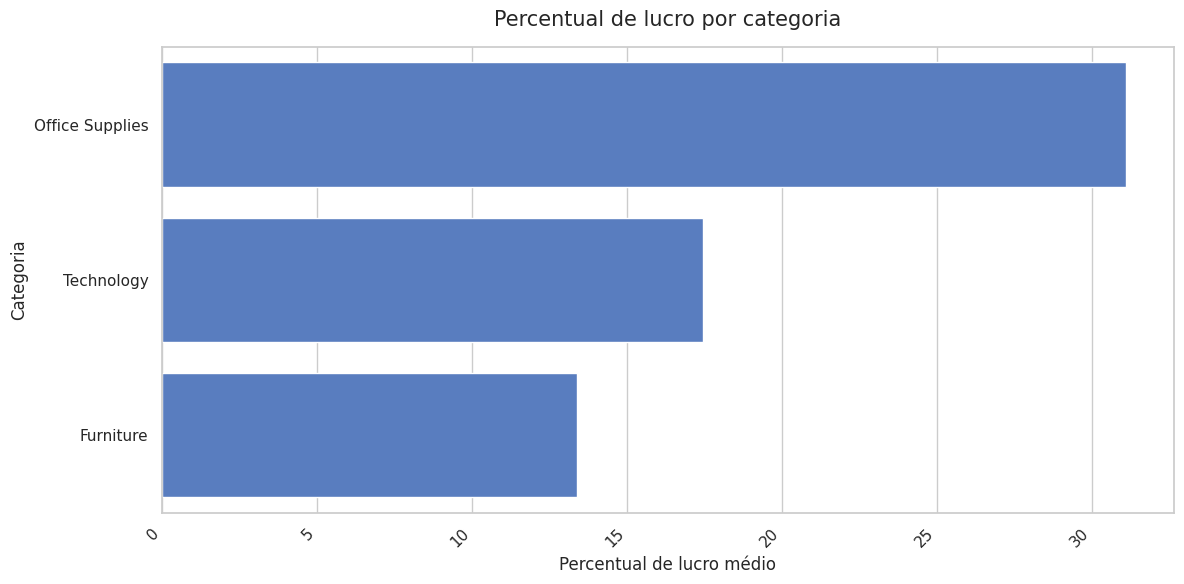

[Sucesso] 3 gráficos salvos em: /content/drive/MyDrive/Colab Notebooks/Projeto 1


In [52]:
#gerar visualizações
def gerar_visual(df_v2, metricas, clientes, output_dir="/content/drive/MyDrive/Colab Notebooks/Projeto 1"):
#estilo layout
  sns.set_theme(style="whitegrid", palette="muted")
#pasta de destino
  os.makedirs(output_dir, exist_ok=True)

  # grafico de linha receita por mês
  fig, ax = plt.subplots(figsize=(12, 6))
  sns.lineplot(data=metricas["por_mes"], x="Ano_mes", y="receita_total", ax=ax)
  ax.set_title("Receita por mês", fontsize=15, pad=15)
  ax.set_xlabel("Mês")
  ax.set_ylabel("Receita(U$)")
  plt.xticks(rotation=90, ha="right")
  fig.tight_layout()

  fig.savefig(os.path.join(output_dir, "receita_por_mes.png"))
  plt.show()
  plt.close(fig)


# Top 5 produtos em vendas
  fig, ax = plt.subplots(figsize=(12, 6))
  sns.barplot(data=metricas['top_5_produtos_em_vendas'], x='Sales', y='Product Name', ax=ax)

  ax.set_title("Top 5 Produtos em Vendas", fontsize=15, pad=15)
  ax.set_xlabel("Receita(U$)")
  ax.set_ylabel ("Produto")
  plt.xticks(rotation=90, ha="right")
  fig.tight_layout()
  fig.savefig(os.path.join(output_dir, "top_5_produtos_em_vendas.png"))
  plt.show()
  plt.close(fig)

# percentual_lucro_categoria
  fig, ax =plt.subplots(figsize=(12, 6))
  sns.barplot(data=metricas["percentual_lucro_categoria"], x="Margem_de_Lucro_média", y="Category", ax=ax)
  ax.set_title("Percentual de lucro por categoria", fontsize=15, pad=15)
  ax.set_xlabel("Percentual de lucro médio")
  ax.set_ylabel("Categoria")
  plt.xticks(rotation=45, ha="right")
  fig.tight_layout()
  fig.savefig(os.path.join(output_dir, "percentual_lucro_categoria.png"))
  plt.show()



  # Chamada da função
  print(f"[Sucesso] 3 gráficos salvos em: {output_dir}")
gerar_visual(df_v2, metricas, clientes)

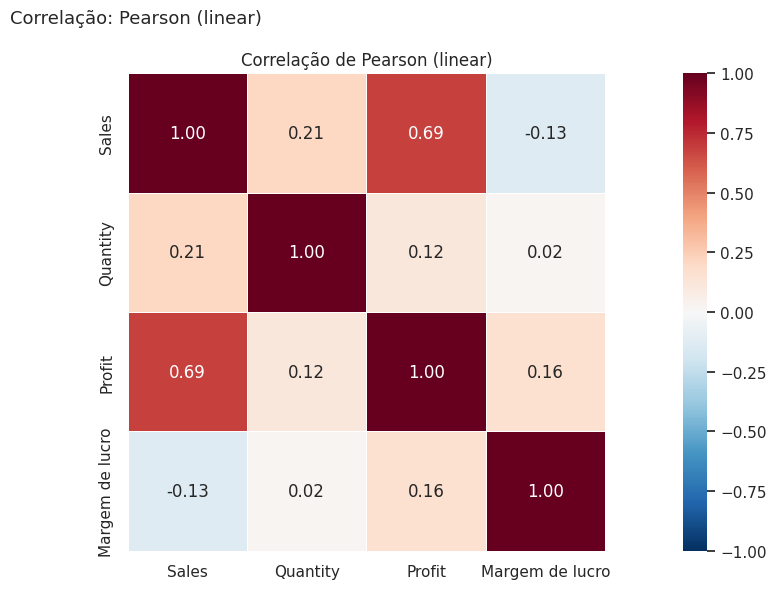

In [53]:
numericas = ['Sales', 'Quantity', 'Profit', 'Margem de lucro']
fig, ax = plt.subplots(1, figsize=(16, 6))
# Removed the loop as plt.subplots(1, ...) returns a single Axes object directly
metodo = 'pearson'
titulo = 'Pearson (linear)'
corr = df_v2[numericas].corr(method=metodo)
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdBu_r',
            vmin=-1, vmax=1, ax=ax, square=True, linewidths=0.5)
ax.set_title(f'Correlação de {titulo}', fontsize=12)

# Updated suptitle to reflect only Pearson correlation is being shown
plt.suptitle(f'Correlação: {titulo}', fontsize=13)
plt.tight_layout()

# Save the figure
output_dir = "/content/drive/MyDrive/Colab Notebooks/Projeto 1"
fig.savefig(os.path.join(output_dir, "correlacao_pearson.png"))

plt.show()

In [54]:
# Ler e escrever arquivos

def exportar_resultados(df_v2, metricas, clientes, stats):
  metricas['por_mes'].to_csv("/content/drive/MyDrive/Colab Notebooks/Projeto 1/US Superstore data (1)_v2_por_mes.csv", index=False, encoding="utf-8-sig")

  clientes.to_csv("/content/drive/MyDrive/Colab Notebooks/Projeto 1/US Superstore data (1)_v2_clientes.csv", index=False, encoding="utf-8-sig")
  print("CSV Exportados.")

  serial = {k: round(float(v),2) for k, v in stats.items()}
  with open("/content/drive/MyDrive/Colab Notebooks/Projeto 1/US Superstore data (1)_v2_stats.json", "w",encoding="utf-8") as f:
    json.dump(serial, f,indent=2,ensure_ascii=False)

  with open("/content/drive/MyDrive/Colab Notebooks/Projeto 1/US Superstore data (1)_v2_stats.json", "r",encoding="utf-8") as f:
     print("JSON lido de volta:", json.load(f))

exportar_resultados(df_v2, metricas, clientes, stats)

CSV Exportados.
JSON lido de volta: {'media': 240.17, 'mediana': 60.85, 'desvio_padrao': 638.4, 'Total': 2171635.75, 'P25': 19.46, 'P75': 223.95, 'Acima da média': 2155.0}


In [55]:
# Salvar o dataset final
df_v2.to_csv("/content/drive/MyDrive/Colab Notebooks/Projeto 1/US Superstore data_Vfinal.csv", index=False)
print("Dataset final salvo em /content/drive/MyDrive/Colab Notebooks/Projeto 1/US Superstore data_Vfinal.csv | Shape:", df.shape)

Dataset final salvo em /content/drive/MyDrive/Colab Notebooks/Projeto 1/US Superstore data_Vfinal.csv | Shape: (9999, 21)
